In [ ]:
import pandas as pd
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, RepeatedKFold, GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

os.chdir('') # set to project directory

# Read in 
df = pd.read_csv("outputs/tables/ml/ml_ibd_features.csv", index_col="sampleID")


In [ ]:
# Separate metadata
study_ids = df["study_alias"]
labels = df["IBD_group_name"]

# Get index of the "Population" column
pop_col_idx = df.columns.get_loc("Population")

# Features = all columns after "Population" (taxa)
features = df.iloc[:, pop_col_idx + 1:]

In [ ]:
le = LabelEncoder()
le.classes_ = np.array(["HC", "IBD"]) # Explicitly fix class order to ensure consistent label encoding
y = le.transform(labels)

In [ ]:
# --------- Config ---------
param_grid = {'max_features': ['sqrt', 'log2', None]}
unique_studies = study_ids.unique()

# --------- Helper ---------
def fit_and_score(X_train, y_train, X_test, y_test, random_state=1337):
    # guard against single-class sets
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        return np.nan
    grid = GridSearchCV(
        estimator=RandomForestClassifier(n_estimators=1000, min_samples_leaf=2, random_state=random_state),
        param_grid=param_grid,
        scoring='roc_auc',
        cv=3,            
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    y_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, y_prob)

# ========= Mode 1: Per-dataset CV (3-fold, repeated) =========
per_dataset_results = {}
cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=20, random_state=1337) 

for study in unique_studies:
    X_study = features[study_ids == study]
    y_study = y[study_ids == study]
    aucs = []
    for train_idx, test_idx in cv.split(X_study, y_study):
        score = fit_and_score(
            X_study.iloc[train_idx], y_study[train_idx],
            X_study.iloc[test_idx],  y_study[test_idx],
            random_state=1337
        )
        if not np.isnan(score):
            aucs.append(score)
    per_dataset_results[study] = np.mean(aucs) if aucs else np.nan

# ========= Mode 2: Across-study =========
across_study_results = pd.DataFrame(index=unique_studies, columns=unique_studies, dtype=float)

for train_study in unique_studies:
    X_train = features[study_ids == train_study]
    y_train = y[study_ids == train_study]

    for test_study in unique_studies:
        X_test = features[study_ids == test_study]
        y_test = y[study_ids == test_study]

        if train_study == test_study:
            score = per_dataset_results.get(train_study, np.nan)
        else:
            score = fit_and_score(X_train, y_train, X_test, y_test, random_state=42)
        across_study_results.loc[train_study, test_study] = score

# ========= Mode 3: LODO =========
lodo_results = {}
for test_study in unique_studies:
    train_mask = study_ids != test_study
    test_mask  = study_ids == test_study
    score = fit_and_score(features[train_mask], y[train_mask],
                          features[test_mask],  y[test_mask],
                          random_state=1337)
    lodo_results[test_study] = score

# ========= Post-processing / summary =========
results_with_avg = across_study_results.copy()
results_with_avg['Average'] = results_with_avg.mean(axis=1)
results_with_avg.loc['Average'] = results_with_avg.mean(axis=0)

# LODO row
lodo_series = pd.Series(lodo_results, dtype=float)
results_with_avg.loc['LODO'] = lodo_series.reindex(results_with_avg.columns)
results_with_avg.loc['LODO', 'Average'] = np.nanmean(lodo_series)

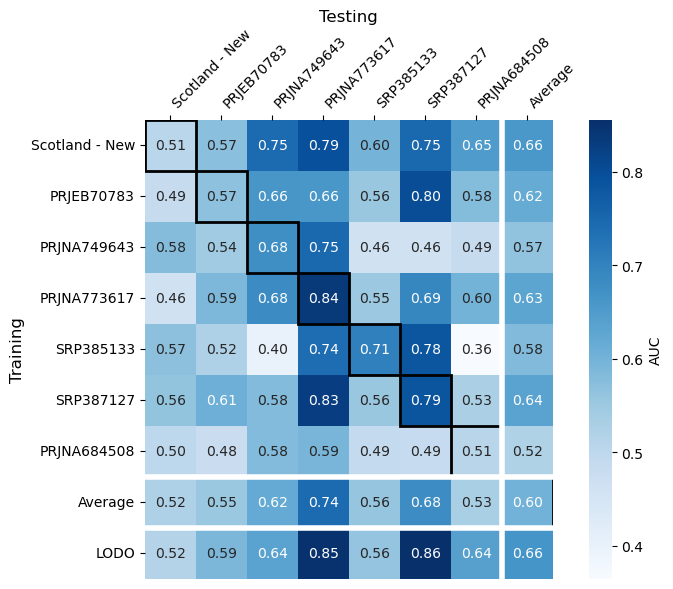

In [ ]:
# Ensure numeric
across_study_results = across_study_results.astype(float)

# Copy and prepare matrix
results_with_avg = across_study_results.copy()

# === Averages ===
results_with_avg['Average'] = results_with_avg.mean(axis=1)  # Row avg
col_avg = results_with_avg.mean(axis=0)
results_with_avg.loc['Average'] = col_avg
results_with_avg.loc['Average', 'Average'] = np.nanmean(across_study_results.to_numpy())

# === LODO Row ===
lodo_series = pd.Series(lodo_results).astype(float)
results_with_avg.loc['LODO'] = lodo_series.reindex(results_with_avg.columns[:-1])  # align order
results_with_avg.loc['LODO', 'Average'] = np.nanmean(lodo_series)

# === Final coercion before plotting ===
heatmap_data = results_with_avg.apply(pd.to_numeric, errors='coerce')

# === Plotting ===
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    heatmap_data, annot=True, cmap="Blues", square=True, fmt=".2f",
    cbar_kws={'label': 'AUC'}
)

# Axis adjustments
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.xticks(rotation=45, ha='left')
plt.yticks(rotation=0)
ax.set_xlabel("Testing", fontsize=12)
plt.ylabel("Training", fontsize=12)

# draw black diagonal boxes (including 'Average')
n = len(across_study_results) + 1
for i in range(n):
    rect = patches.Rectangle((i, i), 1, 1, linewidth=2,
                             edgecolor='black', facecolor='none')
    ax.add_patch(rect)

# === White separator lines ===
if 'LODO' in heatmap_data.index:
    lodo_idx = heatmap_data.index.get_loc('LODO')
    ax.axhline(lodo_idx, color='white', lw=4)

if 'Average' in heatmap_data.index:
    av_idx = heatmap_data.index.get_loc('Average')
    ax.axhline(av_idx, color='white', lw=4)

if 'Average' in heatmap_data.index:
    avy_idx = heatmap_data.index.get_loc('Average')
    ax.axvline(avy_idx, color='white', lw=4)

plt.tight_layout()
plt.savefig("AUC_heatmap_clr_IBD.png", dpi=300)
plt.show()
plt.close()

## Disease sub-type modelling

### CD

In [ ]:
# read in data
cd = pd.read_csv("outputs/tables/ml/ml_cd_features.csv", index_col="sampleID")

In [8]:
# Separate metadata
study_ids = cd["study_alias"]
labels = cd["study_group_name"]

# Get index of the "Population" column
pop_col_idx = cd.columns.get_loc("Population")

# Features = all columns after "Population"
features = cd.iloc[:, pop_col_idx + 1:]

In [9]:
le = LabelEncoder()
le.classes_ = np.array(["HC", "CD"])  # enforce order
y = le.transform(labels)

In [ ]:
# --------- Config ---------
param_grid = {'max_features': ['sqrt', 'log2', None]}
unique_studies = study_ids.unique()

# --------- Helper ---------
def fit_and_score(X_train, y_train, X_test, y_test, random_state=1337):
    # guard against single-class sets
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        return np.nan
    grid = GridSearchCV(
        estimator=RandomForestClassifier(n_estimators=1000, min_samples_leaf=2, random_state=random_state),
        param_grid=param_grid,
        scoring='roc_auc',
        cv=3,            
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    y_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, y_prob)

# ========= Mode 1: Per-dataset CV (3-fold, repeated) =========
per_dataset_results = {}
cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=20, random_state=1337) 

for study in unique_studies:
    X_study = features[study_ids == study]
    y_study = y[study_ids == study]
    aucs = []
    for train_idx, test_idx in cv.split(X_study, y_study):
        score = fit_and_score(
            X_study.iloc[train_idx], y_study[train_idx],
            X_study.iloc[test_idx],  y_study[test_idx],
            random_state=1337
        )
        if not np.isnan(score):
            aucs.append(score)
    per_dataset_results[study] = np.mean(aucs) if aucs else np.nan

# ========= Mode 2: Across-study =========
across_study_results = pd.DataFrame(index=unique_studies, columns=unique_studies, dtype=float)

for train_study in unique_studies:
    X_train = features[study_ids == train_study]
    y_train = y[study_ids == train_study]

    for test_study in unique_studies:
        X_test = features[study_ids == test_study]
        y_test = y[study_ids == test_study]

        if train_study == test_study:
            score = per_dataset_results.get(train_study, np.nan)
        else:
            score = fit_and_score(X_train, y_train, X_test, y_test, random_state=42)
        across_study_results.loc[train_study, test_study] = score

# ========= Mode 3: LODO =========
lodo_results = {}
for test_study in unique_studies:
    train_mask = study_ids != test_study
    test_mask  = study_ids == test_study
    score = fit_and_score(features[train_mask], y[train_mask],
                          features[test_mask],  y[test_mask],
                          random_state=1337)
    lodo_results[test_study] = score

# ========= Post-processing / summary =========
results_with_avg = across_study_results.copy()
results_with_avg['Average'] = results_with_avg.mean(axis=1)
results_with_avg.loc['Average'] = results_with_avg.mean(axis=0)

# LODO row
lodo_series = pd.Series(lodo_results, dtype=float)
results_with_avg.loc['LODO'] = lodo_series.reindex(results_with_avg.columns)
results_with_avg.loc['LODO', 'Average'] = np.nanmean(lodo_series)

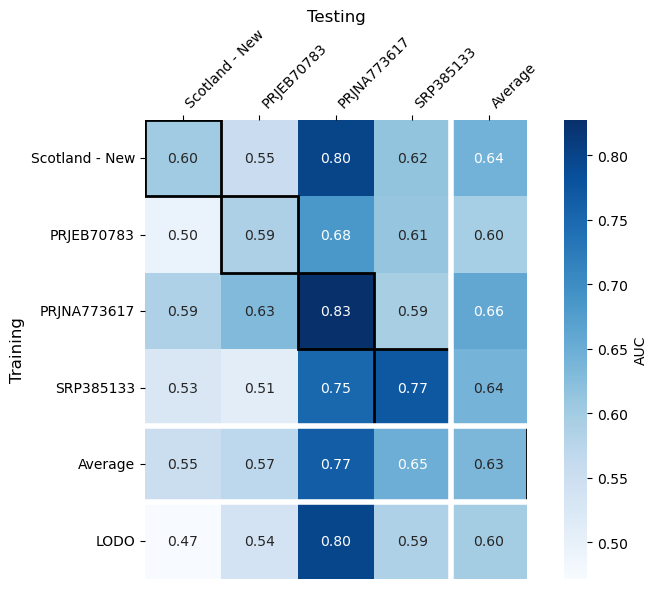

In [12]:
# Ensure numeric
across_study_results = across_study_results.astype(float)

# Copy and prepare matrix
results_with_avg = across_study_results.copy()

# === Averages ===
results_with_avg['Average'] = results_with_avg.mean(axis=1)  # Row avg
col_avg = results_with_avg.mean(axis=0)
results_with_avg.loc['Average'] = col_avg
results_with_avg.loc['Average', 'Average'] = np.nanmean(across_study_results.to_numpy())

# === LODO Row ===
lodo_series = pd.Series(lodo_results).astype(float)
results_with_avg.loc['LODO'] = lodo_series.reindex(results_with_avg.columns[:-1])  # align order
results_with_avg.loc['LODO', 'Average'] = np.nanmean(lodo_series)

# === Final coercion before plotting ===
heatmap_data = results_with_avg.apply(pd.to_numeric, errors='coerce')

# === Plotting ===
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    heatmap_data, annot=True, cmap="Blues", square=True, fmt=".2f",
    cbar_kws={'label': 'AUC'}
)

# Axis adjustments
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.xticks(rotation=45, ha='left')
plt.yticks(rotation=0)
ax.set_xlabel("Testing", fontsize=12)
plt.ylabel("Training", fontsize=12)

# === Optional: draw black diagonal boxes (including 'Average') ===
n = len(across_study_results) + 1
for i in range(n):
    rect = patches.Rectangle((i, i), 1, 1, linewidth=2,
                             edgecolor='black', facecolor='none')
    ax.add_patch(rect)

# === White separator lines ===
if 'LODO' in heatmap_data.index:
    lodo_idx = heatmap_data.index.get_loc('LODO')
    ax.axhline(lodo_idx, color='white', lw=4)

if 'Average' in heatmap_data.index:
    av_idx = heatmap_data.index.get_loc('Average')
    ax.axhline(av_idx, color='white', lw=4)

if 'Average' in heatmap_data.index:
    avy_idx = heatmap_data.index.get_loc('Average')
    ax.axvline(avy_idx, color='white', lw=4)

plt.tight_layout()
plt.savefig("AUC_heatmap_CD_10000.png", dpi=300)
plt.show()
plt.close()

## UC

In [ ]:
uc = pd.read_csv("outputs/tables/ml/ml_uc_features.csv", index_col="sampleID")

In [15]:
# Separate metadata
study_ids = uc["study_alias"]
labels = uc["study_group_name"]

# Get index of the "Population" column
pop_col_idx = uc.columns.get_loc("Population")

# Features = all columns after "Population"
features = uc.iloc[:, pop_col_idx + 1:]

In [17]:
le = LabelEncoder()
le.classes_ = np.array(["HC", "UC"])  # enforce order
y = le.transform(labels)

In [ ]:
# --------- Config ---------
param_grid = {'max_features': ['sqrt', 'log2', None]}
unique_studies = study_ids.unique()

# --------- Helper ---------
def fit_and_score(X_train, y_train, X_test, y_test, random_state=1337):
    # guard against single-class sets
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        return np.nan
    grid = GridSearchCV(
        estimator=RandomForestClassifier(n_estimators=1000, min_samples_leaf=2, random_state=random_state),
        param_grid=param_grid,
        scoring='roc_auc',
        cv=3,            
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    y_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, y_prob)

# ========= Mode 1: Per-dataset CV (3-fold, repeated) =========
per_dataset_results = {}
cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=20, random_state=1337) 

for study in unique_studies:
    X_study = features[study_ids == study]
    y_study = y[study_ids == study]
    aucs = []
    for train_idx, test_idx in cv.split(X_study, y_study):
        score = fit_and_score(
            X_study.iloc[train_idx], y_study[train_idx],
            X_study.iloc[test_idx],  y_study[test_idx],
            random_state=1337
        )
        if not np.isnan(score):
            aucs.append(score)
    per_dataset_results[study] = np.mean(aucs) if aucs else np.nan

# ========= Mode 2: Across-study =========
across_study_results = pd.DataFrame(index=unique_studies, columns=unique_studies, dtype=float)

for train_study in unique_studies:
    X_train = features[study_ids == train_study]
    y_train = y[study_ids == train_study]

    for test_study in unique_studies:
        X_test = features[study_ids == test_study]
        y_test = y[study_ids == test_study]

        if train_study == test_study:
            score = per_dataset_results.get(train_study, np.nan)
        else:
            score = fit_and_score(X_train, y_train, X_test, y_test, random_state=42)
        across_study_results.loc[train_study, test_study] = score

# ========= Mode 3: LODO =========
lodo_results = {}
for test_study in unique_studies:
    train_mask = study_ids != test_study
    test_mask  = study_ids == test_study
    score = fit_and_score(features[train_mask], y[train_mask],
                          features[test_mask],  y[test_mask],
                          random_state=1337)
    lodo_results[test_study] = score

# ========= Post-processing / summary =========
results_with_avg = across_study_results.copy()
results_with_avg['Average'] = results_with_avg.mean(axis=1)
results_with_avg.loc['Average'] = results_with_avg.mean(axis=0)

# LODO row
lodo_series = pd.Series(lodo_results, dtype=float)
results_with_avg.loc['LODO'] = lodo_series.reindex(results_with_avg.columns)
results_with_avg.loc['LODO', 'Average'] = np.nanmean(lodo_series)

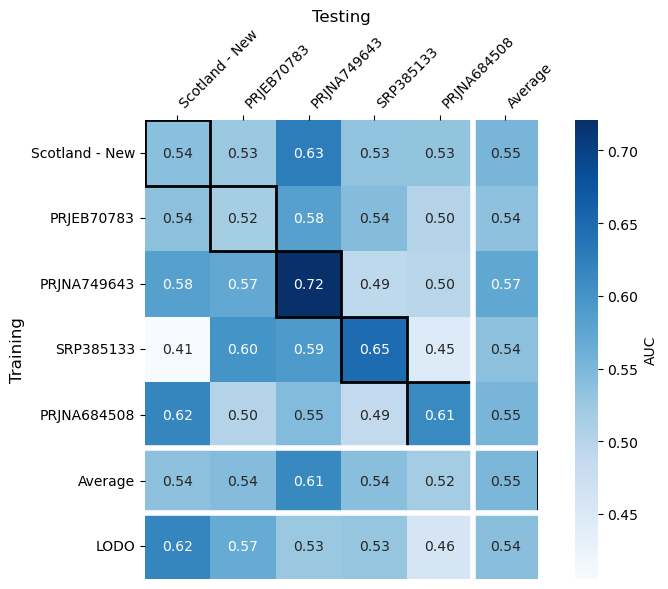

In [19]:
# Ensure numeric
across_study_results = across_study_results.astype(float)

# Copy and prepare matrix
results_with_avg = across_study_results.copy()

# === Averages ===
results_with_avg['Average'] = results_with_avg.mean(axis=1)  # Row avg
col_avg = results_with_avg.mean(axis=0)
results_with_avg.loc['Average'] = col_avg
results_with_avg.loc['Average', 'Average'] = np.nanmean(across_study_results.to_numpy())

# === LODO Row ===
lodo_series = pd.Series(lodo_results).astype(float)
results_with_avg.loc['LODO'] = lodo_series.reindex(results_with_avg.columns[:-1])  # align order
results_with_avg.loc['LODO', 'Average'] = np.nanmean(lodo_series)

# === Final coercion before plotting ===
heatmap_data = results_with_avg.apply(pd.to_numeric, errors='coerce')

# === Plotting ===
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    heatmap_data, annot=True, cmap="Blues", square=True, fmt=".2f",
    cbar_kws={'label': 'AUC'}
)

# Axis adjustments
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.xticks(rotation=45, ha='left')
plt.yticks(rotation=0)
ax.set_xlabel("Testing", fontsize=12)
plt.ylabel("Training", fontsize=12)

# === Optional: draw black diagonal boxes (including 'Average') ===
n = len(across_study_results) + 1
for i in range(n):
    rect = patches.Rectangle((i, i), 1, 1, linewidth=2,
                             edgecolor='black', facecolor='none')
    ax.add_patch(rect)

# === White separator lines ===
if 'LODO' in heatmap_data.index:
    lodo_idx = heatmap_data.index.get_loc('LODO')
    ax.axhline(lodo_idx, color='white', lw=4)

if 'Average' in heatmap_data.index:
    av_idx = heatmap_data.index.get_loc('Average')
    ax.axhline(av_idx, color='white', lw=4)

if 'Average' in heatmap_data.index:
    avy_idx = heatmap_data.index.get_loc('Average')
    ax.axvline(avy_idx, color='white', lw=4)

plt.tight_layout()
plt.savefig("AUC_heatmap_UC_10000.png", dpi=300)
plt.show()
plt.close()